# Predicting Employee Attrition with Logistic Regression

**Salifort Motors · Google Advanced Data Analytics Capstone**

Employee turnover can increase recruitment costs, disrupt productivity, and reduce organizational knowledge. This project analyzes workforce data and develops a logistic regression model to identify factors associated with attrition and estimate which employees may be at greater risk of leaving.


## Business Context

Salifort Motors' Human Resources team wants to understand the factors contributing to employee turnover and use those insights to support more effective retention strategies.


### Project Objective and Stakeholders

The primary stakeholders are Salifort Motors' Human Resources department and senior leadership team. The objective is to identify workplace factors associated with attrition, build an interpretable predictive model, and translate the findings into actionable retention recommendations.


In [1]:
# Import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Standardize Column Names

In [5]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df0 = df0.rename(columns={
    "average_montly_hours": "average_monthly_hours",
    "Work_accident": "work_accident",
    "Department": "department"
})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Missing Values

In [7]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Duplicate Records

In [8]:
# Check for duplicates
df0.duplicated().sum()

3008

In [9]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated(keep=False)].sort_values(
    by=list(df0.columns)
).head(20)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
30,0.09,0.62,6,294,4,0,1,0,accounting,low
12030,0.09,0.62,6,294,4,0,1,0,accounting,low
14241,0.09,0.62,6,294,4,0,1,0,accounting,low
71,0.09,0.77,5,275,4,0,1,0,product_mng,medium
12071,0.09,0.77,5,275,4,0,1,0,product_mng,medium
14282,0.09,0.77,5,275,4,0,1,0,product_mng,medium
652,0.09,0.77,6,290,4,0,1,0,technical,medium
12652,0.09,0.77,6,290,4,0,1,0,technical,medium
14863,0.09,0.77,6,290,4,0,1,0,technical,medium
278,0.09,0.78,6,254,4,0,1,0,support,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df0.drop_duplicates().copy()

# Display first few rows of new dataframe as needed
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Outlier Review

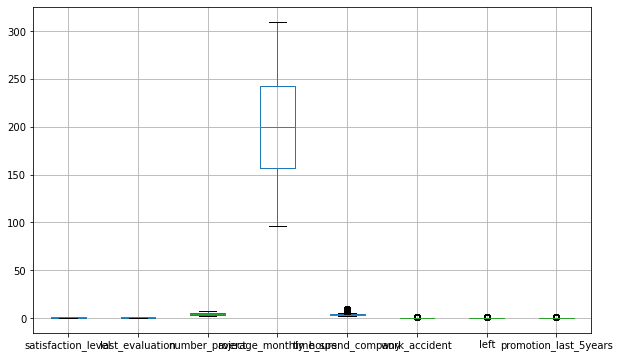

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
df1.boxplot(figsize=(10, 6))

In [12]:
# Determine the number of rows containing outliers
Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df1[
    (df1['time_spend_company'] < lower_limit) |
    (df1['time_spend_company'] > upper_limit)
]

print("Number of rows containing outliers:", len(outliers))

Number of rows containing outliers: 824


## Exploratory Data Analysis

Initial exploration suggested meaningful relationships between employee tenure, workload, satisfaction, and turnover. The following analysis examines distributions and feature relationships in greater detail.


In [13]:
# Get numbers of people who left vs. stayed
df1['left'].value_counts()

# Get percentages of people who left vs. stayed
df1['left'].value_counts(normalize=True)

0    0.833959
1    0.166041
Name: left, dtype: float64

### Data Visualizations

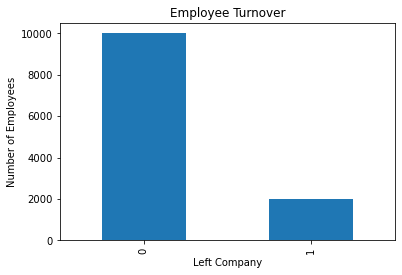

In [14]:
# Create a plot as needed
import matplotlib.pyplot as plt

df1['left'].value_counts().plot(kind='bar')

plt.title('Employee Turnover')
plt.xlabel('Left Company')
plt.ylabel('Number of Employees')
plt.show()

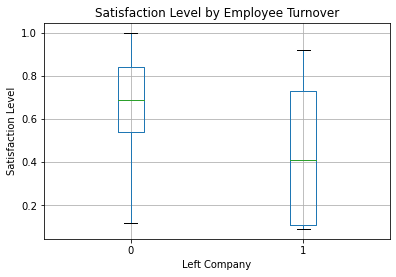

In [15]:
# Create a plot as needed
df1.boxplot(column='satisfaction_level', by='left')

plt.title('Satisfaction Level by Employee Turnover')
plt.suptitle('')
plt.xlabel('Left Company')
plt.ylabel('Satisfaction Level')
plt.show()

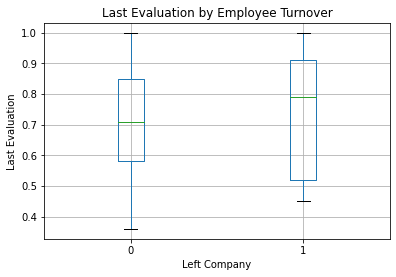

In [16]:
# Create a plot as needed
df1.boxplot(column='last_evaluation', by='left')

plt.title('Last Evaluation by Employee Turnover')
plt.suptitle('')
plt.xlabel('Left Company')
plt.ylabel('Last Evaluation')
plt.show()

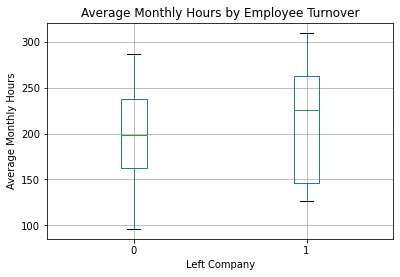

In [17]:
# Create a plot as needed
df1.boxplot(column='average_monthly_hours', by='left')

plt.title('Average Monthly Hours by Employee Turnover')
plt.suptitle('')
plt.xlabel('Left Company')
plt.ylabel('Average Monthly Hours')
plt.show()

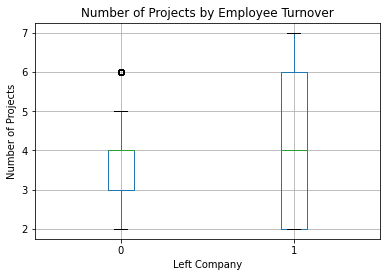

In [18]:
# Create a plot as needed
df1.boxplot(column='number_project', by='left')

plt.title('Number of Projects by Employee Turnover')
plt.suptitle('')
plt.xlabel('Left Company')
plt.ylabel('Number of Projects')
plt.show()

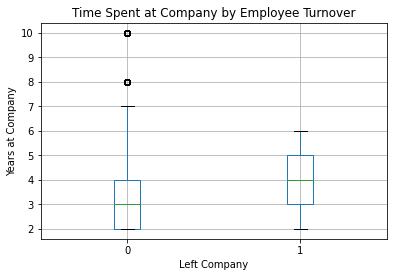

In [19]:
# Create a plot as needed
df1.boxplot(column='time_spend_company', by='left')

plt.title('Time Spent at Company by Employee Turnover')
plt.suptitle('')
plt.xlabel('Left Company')
plt.ylabel('Years at Company')
plt.show()

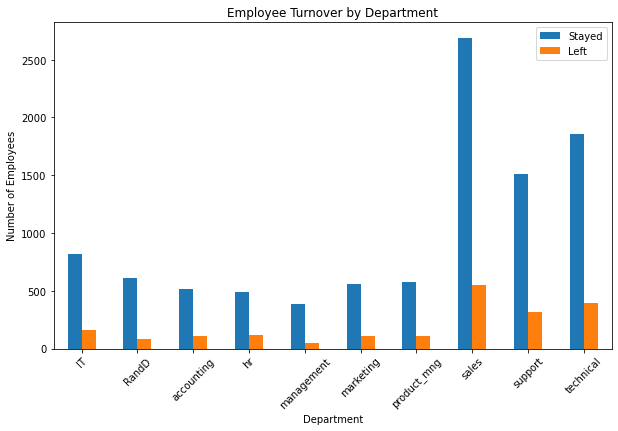

In [20]:
# Create a plot as needed
department_turnover = pd.crosstab(df1['department'], df1['left'])

department_turnover.plot(kind='bar', figsize=(10, 6))

plt.title('Employee Turnover by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.legend(['Stayed', 'Left'])
plt.show()

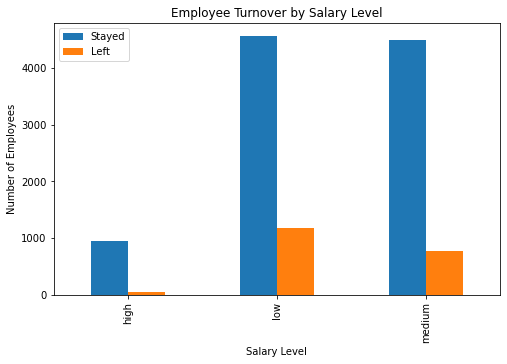

In [21]:
# Create a plot as needed
salary_turnover = pd.crosstab(df1['salary'], df1['left'])

salary_turnover.plot(kind='bar', figsize=(8, 5))

plt.title('Employee Turnover by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.legend(['Stayed', 'Left'])
plt.show()

### Exploratory Insights

The exploratory data analysis identified several factors associated with employee turnover. Employees who left the company generally had lower satisfaction levels, worked more monthly hours, handled more projects, and had longer tenure than employees who stayed. Last evaluation scores alone did not strongly distinguish employees who left from those who stayed, suggesting that high-performing employees may also leave when dissatisfied. Turnover was observed across all departments, with higher numbers in larger departments such as Sales, Technical, and Support. Employees with low and medium salary levels accounted for most departures, indicating that compensation may also be related to employee retention. These findings suggest that workload, satisfaction, tenure, and salary are likely to be important predictors in the predictive modeling stage.

## Model Development

Logistic regression was selected as an interpretable baseline model for this binary classification task. Predictor variables were prepared, categorical features were encoded, numerical features were standardized, and the model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.


### Prediction Task

This is a binary classification problem: predict whether an employee will leave the company (`left = 1`) or remain (`left = 0`).


### Model Selection

Logistic regression was chosen because it provides an interpretable baseline for estimating employee attrition risk and understanding the direction of relationships between predictors and turnover.


In [22]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [23]:
# Prepare the data
# Create dummy variables
df_model = pd.get_dummies(
    df1,
    columns=['department', 'salary'],
    drop_first=True
)

# Define predictor and outcome variables
X = df_model.drop(columns='left')
y = df_model['left']

In [24]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [25]:
# Train the model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [27]:
# Make predictions on the test data
y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

In [28]:
# Generate a confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[2399,  101],
       [ 396,  102]])

In [29]:
# Generate a classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2500
           1       0.50      0.20      0.29       498

    accuracy                           0.83      2998
   macro avg       0.68      0.58      0.60      2998
weighted avg       0.80      0.83      0.80      2998



In [30]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC:", auc)

Accuracy: 0.8342228152101401
Precision: 0.5024630541871922
Recall: 0.20481927710843373
F1 Score: 0.29101283880171186
AUC: 0.8289373493975902


## Results and Business Recommendations

The logistic regression model achieved approximately 83.4% accuracy and an ROC-AUC of 0.83. However, recall for employees who left was only about 20.5%, indicating that the model identified employees who stayed more effectively than employees who departed.

The model should therefore be treated as an early screening tool rather than the sole basis for retention decisions. Recommended actions include monitoring sustained workloads and monthly hours, improving work-life balance, measuring employee satisfaction regularly, and reviewing management practices. Future modeling should address class imbalance and compare logistic regression with tree-based methods.


### Model Performance

The model achieved 83.4% accuracy and an ROC-AUC of 0.83, demonstrating good overall discrimination. Its low recall for departing employees remains the primary limitation.


### Conclusion and Next Steps

Employee turnover was associated with workload, working hours, and job satisfaction. Future work should focus on improving recall through class-balancing techniques, additional feature engineering, hyperparameter tuning, and comparison with decision trees, Random Forest, or gradient boosting models.

Employee data should remain confidential, and predictions should support—not replace—human judgment.
